# Life Expectancy Prediction

**Mission:** Predict life expectancy from health/economic indicators so we can see which factors matter for public health planning.

**Dataset:** WHO Life Expectancy on Kaggle (https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who). Around 2938 country-year rows (2000-2015) with immunization, mortality, BMI, GDP, schooling etc.

Target = life expectancy (years). I pick the best model using lowest test RMSE.

In [ ]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "linear_regression":
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT))

from summative.linear_regression.training import (
    FEATURES,
    TARGET,
    clean_data,
    fit_models,
    load_data,
    sgd_loss_curve,
)

DATA = ROOT / "summative/linear_regression/data/life_expectancy.csv"
MODEL = ROOT / "summative/linear_regression/artifacts/best_model.joblib"
METRICS = ROOT / "summative/linear_regression/artifacts/model_metrics.json"
PLOTS = ROOT / "summative/linear_regression/plots"

raw = pd.read_csv(DATA)
print(raw.shape)
raw.head()

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Feature engineering

Dropped:
- Country (just a name)
- Year (not useful for a general prediction API)
- infant deaths / under-five deaths (very similar to each other)
- population, measles, thinness columns (lots of missing / weak)
- some immunization duplicates (kept polio)

Kept status, adult mortality, alcohol, BMI, polio, HIV/AIDS, GDP, income composition, schooling.

Status converted Developing/Developed -> 0/1.
Missing values filled with median and data is standardized for SGD.

features: ['status', 'adult_mortality', 'alcohol', 'bmi', 'polio', 'hiv_aids', 'gdp', 'income_composition', 'schooling']
(2928, 10)


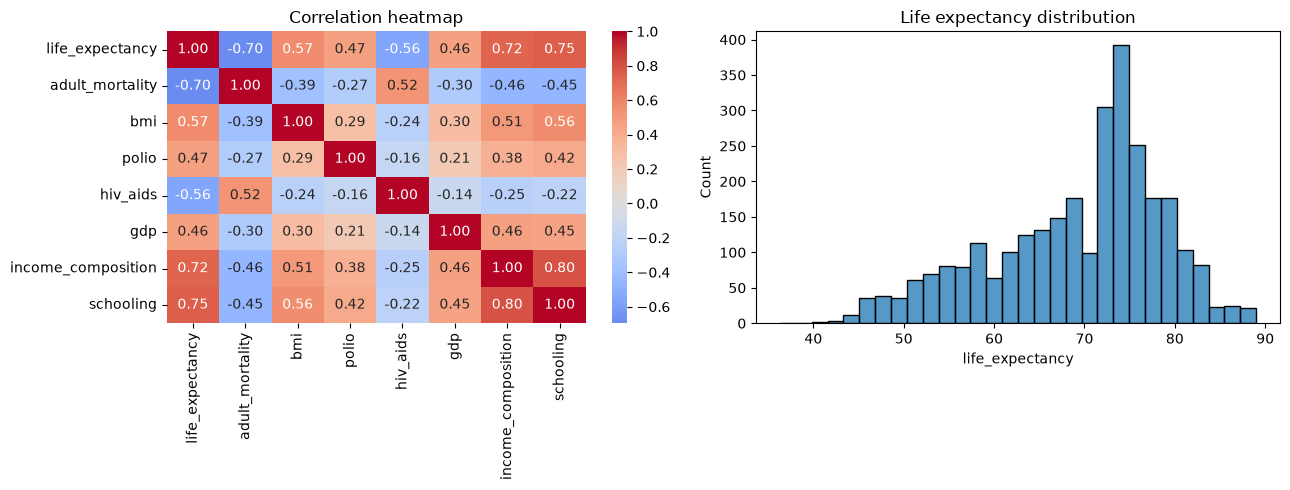

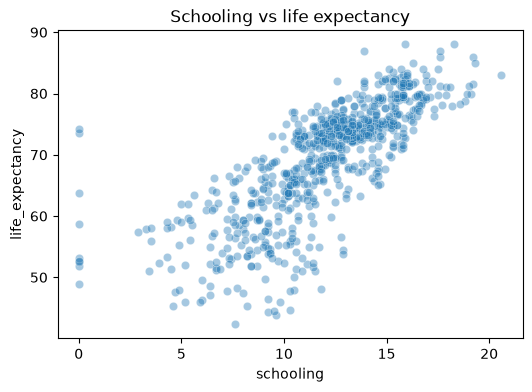

In [ ]:
df = clean_data(load_data(DATA))
print("features:", FEATURES)
print(df.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
heat = ["life_expectancy", "adult_mortality", "bmi", "polio", "hiv_aids", "gdp", "income_composition", "schooling"]
sns.heatmap(df[heat].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation heatmap")
sns.histplot(df[TARGET], bins=30, ax=axes[1])
axes[1].set_title("Life expectancy distribution")
plt.tight_layout()
plt.show()

# schooling seems strongly related to life expectancy
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df.sample(800, random_state=42), x="schooling", y=TARGET, alpha=0.4)
plt.title("Schooling vs life expectancy")
plt.show()

In [ ]:
models, metrics, split = fit_models(load_data(DATA))
results = pd.DataFrame(metrics).T.sort_values("test_rmse")
display(results)

best_name = results.index[0]
best_model = models[best_name]
print("best model:", best_name, "test RMSE =", round(results.iloc[0]["test_rmse"], 3))

,train_rmse,test_rmse,test_mae,test_r2
Random Forest,0.937676,1.793001,1.124722,0.962834
Decision Tree,1.469611,2.478111,1.634384,0.929005
Ordinary Linear Regression,4.284864,4.117480,3.041133,0.804003
SGD Linear Regression,4.294098,4.133172,3.064326,0.802506


best model: Random Forest test RMSE = 1.793


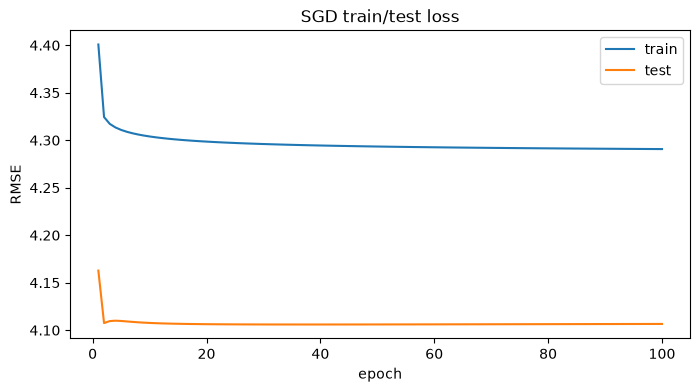

In [ ]:
X_train, X_test, y_train, y_test = split
history = sgd_loss_curve(X_train, X_test, y_train, y_test)

plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], history["train_rmse"], label="train")
plt.plot(history["epoch"], history["test_rmse"], label="test")
plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.title("SGD train/test loss")
plt.legend()
plt.show()

/Users/apple/Documents/linear_regression_model/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


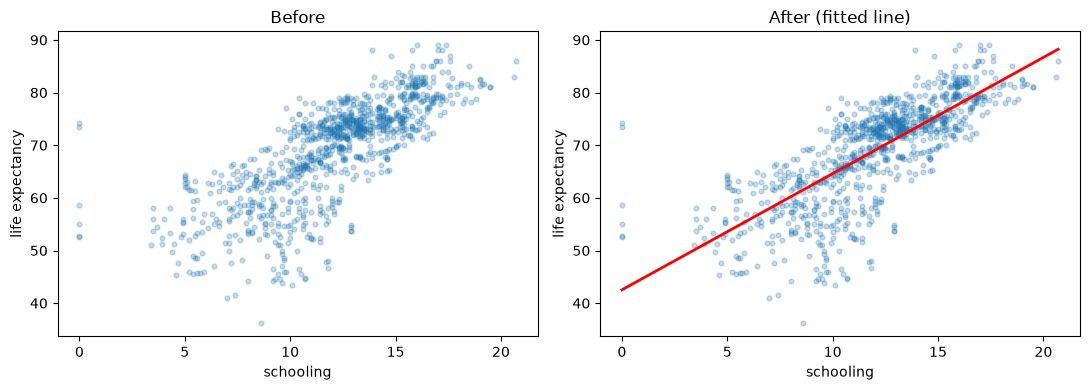

In [ ]:
from sklearn.linear_model import LinearRegression

# before and after linear line using schooling
sample = df.dropna(subset=["schooling"]).sample(1000, random_state=42)
line = LinearRegression().fit(sample[["schooling"]], sample[TARGET])
xs = np.linspace(sample["schooling"].min(), sample["schooling"].max(), 100).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(sample["schooling"], sample[TARGET], alpha=0.25, s=12)
axes[0].set_title("Before")
axes[1].scatter(sample["schooling"], sample[TARGET], alpha=0.25, s=12)
axes[1].plot(xs, line.predict(xs), color="red", linewidth=2)
axes[1].set_title("After (fitted line)")
for ax in axes:
    ax.set_xlabel("schooling")
    ax.set_ylabel("life expectancy")
plt.tight_layout()
plt.show()

In [ ]:
import json
from summative.linear_regression.training import train_and_save

MODEL.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {
        "model": best_model,
        "model_name": best_name,
        "features": FEATURES,
        "metrics": metrics[best_name],
    },
    MODEL,
    compress=3,
)
METRICS.write_text(json.dumps({"best_model": best_name, "models": metrics}, indent=2))
train_and_save(DATA, MODEL, METRICS, PLOTS)
print("saved:", MODEL)

# predict one row from test set
one = X_test.iloc[[0]]
actual = float(y_test.iloc[0])
pred = float(best_model.predict(one)[0])
display(one)
print("actual:", actual, "predicted:", round(pred, 2))

saved: /Users/apple/Documents/linear_regression_model/summative/linear_regression/artifacts/best_model.joblib


,status,adult_mortality,alcohol,bmi,polio,hiv_aids,gdp,income_composition,schooling
2399,0,449.0,7.6,46.4,75.0,19.0,5888.6284,0.622,12.8


actual: 56.5 predicted: 55.37
